In [1]:
import numpy as np
import torch
import random
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from torch import nn
from torch.utils.data import Dataset, DataLoader
from config import config
from tqdm.auto import tqdm
from utils import (
    build_metadata, split_metadata, evaluate_split,
    print_split_summary, preprocess_img,
    sample_pixels, count_by_class, plot_class_distribution
)

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("DEVICE:", config.DEVICE)

DEVICE: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.RANDOM_STATE)

In [4]:
meta = build_metadata(config.DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks:   0%|          | 0/347 [00:00<?, ?it/s]

Scanning masks: 100%|██████████| 347/347 [00:00<00:00, 493.30it/s]


[train] images: 312
  Unknown  pixels=   12,639 images=119
  Greenery pixels=13,767,531 images=298
  Sand     pixels=5,390,336 images=257
  Water    pixels=  374,661 images= 48
  Cement   pixels=  902,065 images=247
  strata: {'cement_only': 206, 'base': 58, 'water_and_cement': 41, 'water_only': 7}
[val] images: 17
  Unknown  pixels=      113 images=  4
  Greenery pixels=  672,984 images= 16
  Sand     pixels=  367,098 images= 14
  Water    pixels=   65,610 images=  3
  Cement   pixels=    8,307 images= 13
  strata: {'cement_only': 11, 'base': 4, 'water_and_cement': 2}
[test] images: 18
  Unknown  pixels=       41 images=  7
  Greenery pixels=  665,187 images= 16
  Sand     pixels=  440,910 images= 16
  Water    pixels=      154 images=  2
  Cement   pixels=   73,356 images= 14
  strata: {'cement_only': 12, 'base': 4, 'water_and_cement': 2}


In [5]:
class LandCoverSegDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.float32)
        mask = self.y[idx].astype(np.int64)
        return torch.from_numpy(img), torch.from_numpy(mask)

In [6]:
def process_pair(img_path, mask_path):
    img, mask, confidence, pixel_valid = preprocess_img(img_path, mask_path)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    img = img.astype(np.float32)
    mask = mask.astype(np.uint8).copy()
    confidence = confidence.astype(np.float32)
    mask[~valid] = 0

    return img, mask, confidence


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []

    for X, y, pixel_weight in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)

    X_all = np.stack(X_parts, axis=0)
    y_all = np.stack(y_parts, axis=0)
    weight_all = np.stack(weight_parts, axis=0)
    return X_all, y_all, weight_all

Building dataset: 100%|██████████| 18/18 [00:00<00:00, 28717.18it/s]


Train full: (312, 12, 256, 256) {'Greenery': 13773606, 'Sand': 5358455, 'Water': 315453, 'Cement': 903472}
Val full  : (17, 12, 256, 256) {'Greenery': 673092, 'Sand': 367098, 'Water': 65610, 'Cement': 8312}
Test full : (18, 12, 256, 256) {'Greenery': 665203, 'Sand': 440916, 'Water': 154, 'Cement': 73375}
Greenery available=13,773,606 sampled=  800,000
Sand     available=5,358,455 sampled=  800,000
Water    available=  315,453 sampled=  315,453
Cement   available=  903,472 sampled=  800,000
Train sampled: (312, 12, 256, 256) {'Greenery': 800000, 'Sand': 800000, 'Water': 315453, 'Cement': 800000}
Val full     : (17, 12, 256, 256) {'Greenery': 673092, 'Sand': 367098, 'Water': 65610, 'Cement': 8312}
Test full    : (18, 12, 256, 256) {'Greenery': 665203, 'Sand': 440916, 'Water': 154, 'Cement': 73375}
Ignored train pixels: 17731779
Train confidence weight range: 0.33000001311302185 1.0


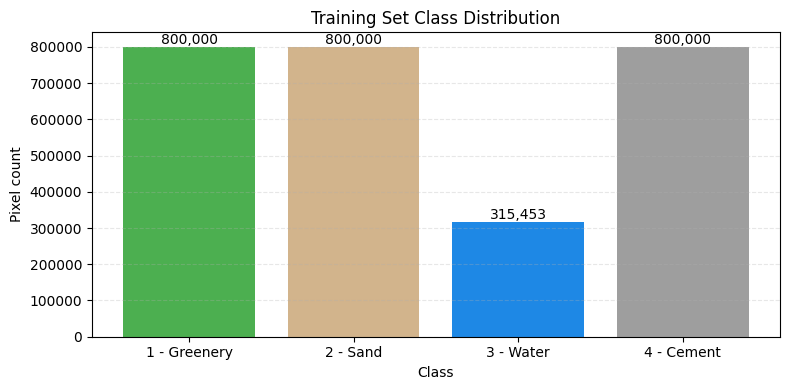

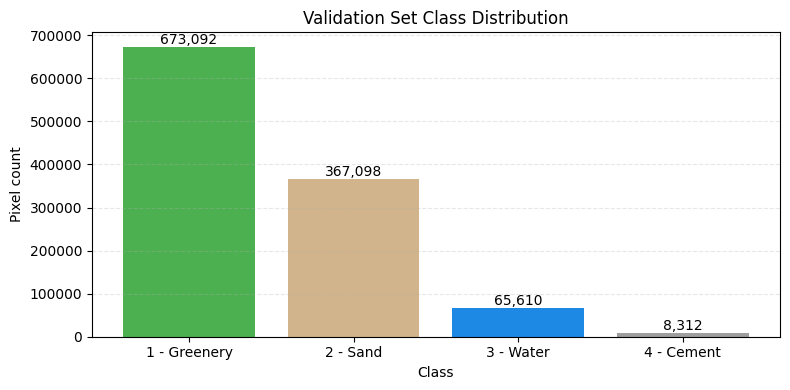

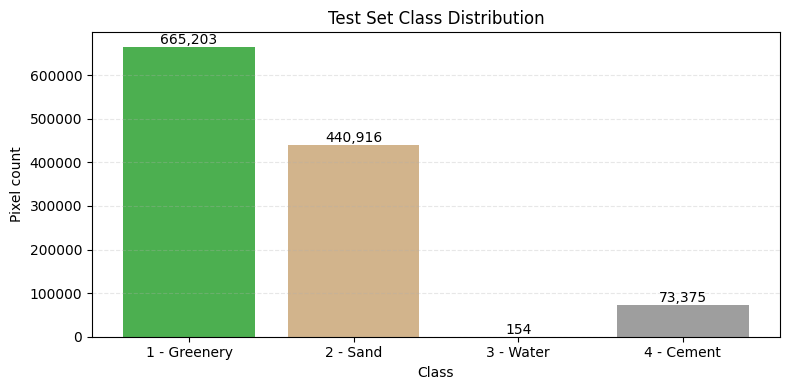

In [7]:
def apply_pixel_caps(masks, confidence, caps):
    flat_y = masks.reshape(-1)
    flat_conf = confidence.reshape(-1) if confidence is not None else None
    valid = flat_y != 0
    flat_idx = np.arange(flat_y.size, dtype=np.int64)

    sampled_idx, sampled_y, sampled_conf = sample_pixels(
        flat_idx[valid],
        flat_y[valid],
        caps,
        flat_conf[valid] if flat_conf is not None else None,
    )

    capped_y = np.zeros_like(flat_y)
    capped_y[sampled_idx] = sampled_y

    capped_conf = None
    if flat_conf is not None:
        capped_conf = np.zeros_like(flat_conf)
        capped_conf[sampled_idx] = sampled_conf

    return capped_y.reshape(masks.shape), None if capped_conf is None else capped_conf.reshape(confidence.shape)


X_train, y_train_full, conf_train_full = build_dataset(train_meta)
X_val, y_val, conf_val = build_dataset(val_meta)
X_test, y_test, conf_test = build_dataset(test_meta)

print('Train full:', X_train.shape, count_by_class(y_train_full[y_train_full != 0]))
print('Val full  :', X_val.shape, count_by_class(y_val[y_val != 0]))
print('Test full :', X_test.shape, count_by_class(y_test[y_test != 0]))

y_train, conf_train = apply_pixel_caps(y_train_full, conf_train_full, config.TRAIN_CAPS_DEEP)

train_valid = y_train != 0
val_valid = y_val != 0
test_valid = y_test != 0

print('Train sampled:', X_train.shape, count_by_class(y_train[train_valid]))
print('Val full     :', X_val.shape, count_by_class(y_val[val_valid]))
print('Test full    :', X_test.shape, count_by_class(y_test[test_valid]))
print('Ignored train pixels:', int((~train_valid).sum()))
print('Train confidence weight range:', float(conf_train[train_valid].min()), float(conf_train[train_valid].max()))
plot_class_distribution(y_train[train_valid], 'Training Set Class Distribution')
plot_class_distribution(y_val[val_valid], 'Validation Set Class Distribution')
plot_class_distribution(y_test[test_valid], 'Test Set Class Distribution')

In [8]:
train_ds = LandCoverSegDataset(X_train, y_train)
val_ds   = LandCoverSegDataset(X_val, y_val)
test_ds  = LandCoverSegDataset(X_test, y_test)


train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Train images with cement:', int(train_meta['has_cement'].sum()))
print('Train images with water :', int(train_meta['has_water'].sum()))

Dataset sizes: 312 17 18
Train images with cement: 247
Train images with water : 48


In [9]:
class UNet(nn.Module):
    def __init__(self, encoder_name="resnet34", num_classes=5):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(12, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 12, kernel_size=1, bias=False),
            nn.BatchNorm2d(12),
            nn.ReLU(inplace=True),
        )

        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=12,
            classes=num_classes,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.unet(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=config.IGNORE_INDEX)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

24.478381 M parameters


In [10]:
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    out = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([8, 12, 256, 256])
Mask shape  : torch.Size([8, 256, 256])
Output shape: torch.Size([8, 5, 256, 256])


In [11]:
def compute_dataset_iou(conf_mat, ignore_index=0):
    ious = []

    for cls in range(conf_mat.shape[0]):
        if cls == ignore_index:
            continue

        tp = conf_mat[cls, cls]
        fp = conf_mat[:, cls].sum() - tp
        fn = conf_mat[cls, :].sum() - tp
        union = tp + fp + fn

        if union > 0:
            ious.append(tp / union)

    return float(np.mean(ious)) if ious else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes=5, ignore_index=0):
    model.eval()
    total_loss = 0.0
    conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)
        valid = masks != ignore_index
        preds_valid = preds[valid]
        masks_valid = masks[valid]

        if masks_valid.numel() > 0:
            indices = (masks_valid.view(-1) * num_classes + preds_valid.view(-1)).to(torch.int64)
            batch_conf = torch.bincount(indices, minlength=num_classes * num_classes)
            conf_mat += batch_conf.reshape(num_classes, num_classes).cpu().numpy()

        total_loss += loss.item()

    mean_loss = total_loss / len(loader)
    mean_iou = compute_dataset_iou(conf_mat, ignore_index=ignore_index)
    return mean_loss, mean_iou, conf_mat

In [12]:
num_epochs = 100
early_stopping_patience = 15
best_val_iou = -1.0
epochs_without_improvement = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_iou, val_conf_mat = validate(
        model,
        val_loader,
        criterion,
        device,
        num_classes=config.NUM_CLASSES,
        ignore_index=config.IGNORE_INDEX,
    )
    scheduler.step(val_iou)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_iou:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_iou > best_val_iou + 1e-4:
        best_val_iou = val_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_unet.pth")
        print("Saved best model")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered")
            break

Training: 100%|██████████| 39/39 [00:06<00:00,  6.28it/s]


Epoch 1/100 | train_loss=1.4775 | val_loss=1.3758 | val_mIoU=0.1517 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 39/39 [00:05<00:00,  6.96it/s]


Epoch 2/100 | train_loss=0.9937 | val_loss=0.7621 | val_mIoU=0.5910 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 39/39 [00:05<00:00,  6.93it/s]


...

Epoch 32/100 | train_loss=0.4587 | val_loss=0.4213 | val_mIoU=0.5989 | lr=7.50e-05


Training: 100%|██████████| 39/39 [00:05<00:00,  6.87it/s]


Epoch 33/100 | train_loss=0.5153 | val_loss=0.3940 | val_mIoU=0.6330 | lr=7.50e-05


Training: 100%|██████████| 39/39 [00:05<00:00,  6.85it/s]


Epoch 34/100 | train_loss=0.4835 | val_loss=0.4508 | val_mIoU=0.5896 | lr=7.50e-05
Early stopping triggered


In [17]:
checkpoint = torch.load("best_unet.pth", map_location=config.DEVICE)
model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(device)
model.load_state_dict(checkpoint)
model.eval()

UNet(
  (stem): Sequential(
    (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (7): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1):

In [18]:
val_loss, val_iou, val_conf_mat = validate(
    model,
    val_loader,
    criterion,
    device,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Validation | loss={val_loss:.4f} | mIoU={val_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = val_conf_mat[cls, cls]
    fp = val_conf_mat[:, cls].sum() - tp
    fn = val_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Validation | loss=0.4681 | mIoU=0.6437
  Greenery IoU: 0.7582
  Sand IoU: 0.5793
  Water IoU: 0.9962
  Cement IoU: 0.2413


In [19]:
@torch.no_grad()
def show_prediction(model, split_df, idx=0):
    if isinstance(model, dict):
        loaded_model = UNet(
            encoder_name="resnet34",
            num_classes=5
        ).to(device)
        loaded_model.load_state_dict(model)
        model = loaded_model

    model.eval()

    row = split_df.iloc[idx]
    image_np, mask_np, _, _ = preprocess_img(row["img_path"], row["mask_path"])

    x = torch.from_numpy(image_np.astype(np.float32)).unsqueeze(0).to(device)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    mask_values, mask_counts = np.unique(mask_np, return_counts=True)
    pred_values, pred_counts = np.unique(pred, return_counts=True)

    print("Mask: ", dict(zip(mask_values, mask_counts)))
    print("Prediction: ", dict(zip(pred_values, pred_counts)))

    rgb = np.transpose(image_np[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

In [1]:
show_prediction(model, train_meta, idx=180)

NameError: name 'show_prediction' is not defined